In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("All imports successful!")

All imports successful!


In [2]:
from sklearn.datasets import fetch_california_housing, load_iris

# Load regression dataset
housing = fetch_california_housing(as_frame=True)
df_reg = housing.frame

# Load classification dataset
iris = load_iris(as_frame=True)
df_cls = iris.frame

print("Regression dataset shape:", df_reg.shape)
print("Classification dataset shape:", df_cls.shape)

Regression dataset shape: (20640, 9)
Classification dataset shape: (150, 5)


In [3]:
# Regression example
X_reg = df_reg.drop(columns=['MedHouseVal'])
y_reg = df_reg['MedHouseVal']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Classification example
X_cls = df_cls.drop(columns=['target'])
y_cls = df_cls['target']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.25, random_state=42
)

print("Training samples (Regression):", X_train_reg.shape[0])
print("Training samples (Classification):", X_train_cls.shape[0])

Training samples (Regression): 16512
Training samples (Classification): 112


In [4]:
from sklearn.linear_model import LinearRegression

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

y_pred_reg = reg_model.predict(X_test_reg)

print("R² Score:", r2_score(y_test_reg, y_pred_reg))

R² Score: 0.575787706032451


In [5]:
log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train_cls, y_train_cls)

y_pred_cls = log_model.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cls, y_pred_cls))
print("\nClassification Report:\n",
      classification_report(y_test_cls, y_pred_cls))

Accuracy: 1.0

Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



In [6]:
from sklearn.pipeline import Pipeline

# Build a pipeline for regression
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train_reg, y_train_reg)

y_pred_pipe = pipeline.predict(X_test_reg)

print("Pipeline R² Score:", r2_score(y_test_reg, y_pred_pipe))

Pipeline R² Score: 0.5757877060324508


In [7]:
import joblib

# Save model
joblib.dump(reg_model, 'linear_model.pkl')

# Load model
loaded_model = joblib.load('linear_model.pkl')

print(
    "Loaded Model R²:",
    r2_score(y_test_reg, loaded_model.predict(X_test_reg))
)

Loaded Model R²: 0.575787706032451


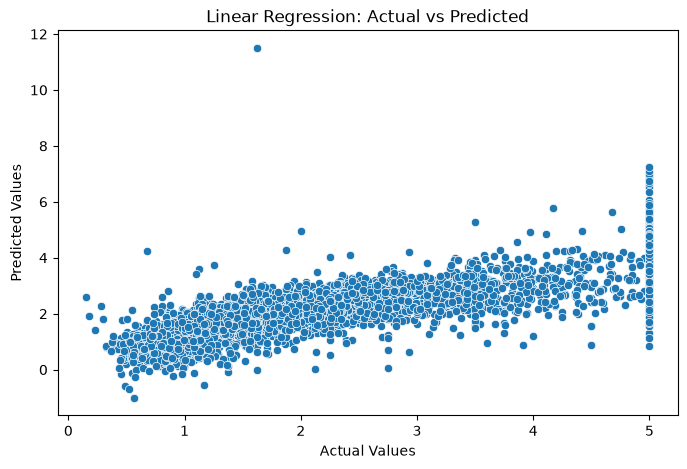

In [8]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_test_reg, y=y_pred_reg)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [9]:
print("Linear Regression R²:", r2_score(y_test_reg, y_pred_reg))
print("Pipeline R²:", r2_score(y_test_reg, y_pred_pipe))

Linear Regression R²: 0.575787706032451
Pipeline R²: 0.5757877060324508


In [10]:
coefficients = pd.DataFrame({
    'Feature': X_train_reg.columns,
    'Coefficient': reg_model.coef_
})

coefficients['Absolute Coefficient'] = coefficients['Coefficient'].abs()

print(coefficients.sort_values(
    by='Absolute Coefficient',
    ascending=False
))

      Feature  Coefficient  Absolute Coefficient
3   AveBedrms     0.783145              0.783145
0      MedInc     0.448675              0.448675
7   Longitude    -0.433708              0.433708
6    Latitude    -0.419792              0.419792
2    AveRooms    -0.123323              0.123323
1    HouseAge     0.009724              0.009724
5    AveOccup    -0.003526              0.003526
4  Population    -0.000002              0.000002


In [11]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_cls, y_train_cls)

y_pred_cls = tree_model.predict(X_test_cls)

print("Accuracy:", accuracy_score(y_test_cls, y_pred_cls))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_cls, y_pred_cls))
print("\nClassification Report:\n", classification_report(y_test_cls, y_pred_cls))

Accuracy: 1.0

Confusion Matrix:
 [[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



Replacing Logistic Regression with Decision Tree Classifier required only changing the estimator and its training code. The evaluation functions remained unchanged because Scikit-learn estimators follow a consistent API. Both models achieved 100% accuracy on this test set, demonstrating the flexibility of the estimator interface.

In [12]:
import pandas as pd

df_articles = pd.read_csv(r"D:\ai-lab-portfolio\lab02\articles.csv")

print("Dataset shape:", df_articles.shape)
print("Columns:", df_articles.columns.tolist())
print(df_articles.head())

Dataset shape: (20, 6)
Columns: ['title', 'text', 'source', 'url', 'sentiment_polarity', 'noun_density']
                                               title  \
0  Top 10 AI Tools That Will Transform Your Conte...   
1  LimeWire AI Studio Review 2023: Details, Prici...   
2  Top 10 AI Tools in 2023 That Will Make Your Li...   
3  Top 10 AI Content Generator & Writer Tools in ...   
4  ProWritingAid VS Grammarly: Which Grammar Chec...   

                                                text         source  \
0  Home Top 10 AI Tools That Will Transform Your ...  TechnCruncher   
1  Home Ai LimeWire AI Studio Review 2023: Detail...  TechnCruncher   
2  Home Ai Top 10 AI Tools in 2023 That Will Make...  TechnCruncher   
3  Home Content Writing Top 10 AI Content Generat...  TechnCruncher   
4  Home Comparison ProWritingAid VS Grammarly: Wh...  TechnCruncher   

                                                 url  sentiment_polarity  \
0  https://techncruncher.blogspot.com/2025/01/top...   

In [13]:
print("Missing values:")
print(df_articles[["text", "sentiment_polarity"]].isnull().sum())

print("\nSentiment polarity median:")
print(df_articles["sentiment_polarity"].median())

Missing values:
text                  0
sentiment_polarity    0
dtype: int64

Sentiment polarity median:
0.176730237201622


In [14]:
X = df_articles["text"]

median_polarity = df_articles["sentiment_polarity"].median()
y = (df_articles["sentiment_polarity"] > median_polarity).astype(int)

print("Total articles:", len(X))
print("\nClass distribution:")
print(y.value_counts().sort_index())

Total articles: 20

Class distribution:
sentiment_polarity
0    10
1    10
Name: count, dtype: int64


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training articles:", len(X_train))
print("Testing articles:", len(X_test))
print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training articles: 16
Testing articles: 4

Training class distribution:
sentiment_polarity
0    8
1    8
Name: count, dtype: int64

Testing class distribution:
sentiment_polarity
0    2
1    2
Name: count, dtype: int64


In [16]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", LogisticRegression(max_iter=1000))
])

sentiment_pipeline.fit(X_train, y_train)

print("Sentiment pipeline trained successfully!")

Sentiment pipeline trained successfully!


In [17]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = sentiment_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.75

Confusion Matrix:
[[1 1]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.67      1.00      0.80         2

    accuracy                           0.75         4
   macro avg       0.83      0.75      0.73         4
weighted avg       0.83      0.75      0.73         4



In [18]:
import joblib

joblib.dump(sentiment_pipeline, "sentiment_pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


In [19]:
loaded_sentiment_pipeline = joblib.load("sentiment_pipeline.pkl")

sample_article = X_test.iloc[0]

prediction = loaded_sentiment_pipeline.predict([sample_article])

print("Raw article text:")
print(sample_article[:300])

print("\nPredicted class:", prediction[0])
print("0 = At or below median polarity")
print("1 = Above median polarity")

Raw article text:
Home → Blog → What Is Jev? TypeSafe’s AI for Decisions Inside Software What Is Jev? TypeSafe’s AI for Decisions Inside Software What Jev does, where typed AI decisions fit, and what our 274-article integration run does—and does not—prove. Published September 20, 2026 · Updated September 20, 2026 ON 

Predicted class: 0
0 = At or below median polarity
1 = Above median polarity


In [20]:
import joblib

loaded_pipeline = joblib.load("sentiment_pipeline.pkl")

sample_text = """What Is Jev? TypeSafe's AI for Decisions Inside Software.
What Jev does, where typed AI decisions fit."""

prediction = loaded_pipeline.predict([sample_text])[0]

print("Reloaded pipeline prediction:", prediction)
print("Class meaning:", 
      "Above median polarity" if prediction == 1
      else "At or below median polarity")

Reloaded pipeline prediction: 0
Class meaning: At or below median polarity


In [21]:
import os

print("Notebook working directory:", os.getcwd())
print("\nSentiment model exists:",
      os.path.exists("sentiment_pipeline.pkl"))
print("Housing model exists:",
      os.path.exists("linear_model.pkl"))

Notebook working directory: D:\ai-lab-portfolio\lab04

Sentiment model exists: True
Housing model exists: True


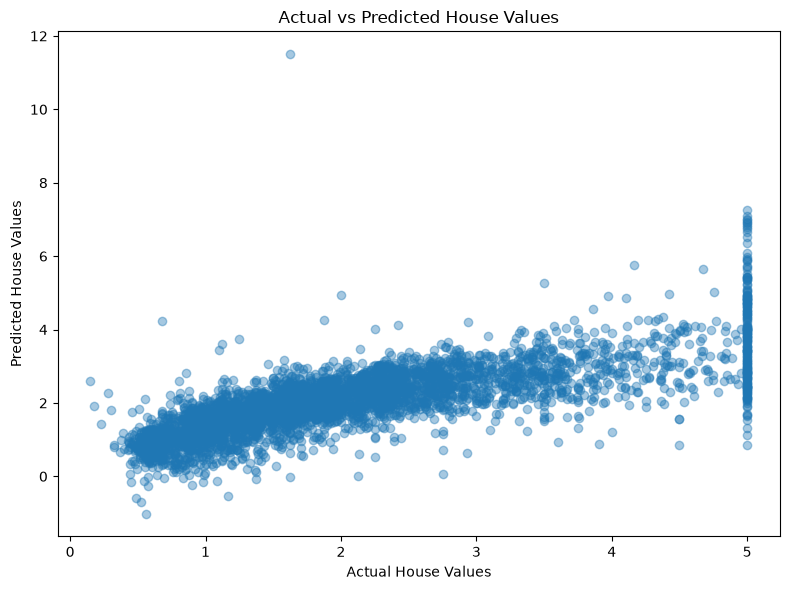

Graph saved: True


In [23]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import os

housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame

X_housing = df_housing.drop(columns=["MedHouseVal"])
y_housing = df_housing["MedHouseVal"]

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

housing_model = LinearRegression()
housing_model.fit(X_train_h, y_train_h)

y_pred_h = housing_model.predict(X_test_h)

os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_h, alpha=0.4)
plt.xlabel("Actual House Values")
plt.ylabel("Predicted House Values")
plt.title("Actual vs Predicted House Values")
plt.tight_layout()
plt.savefig("figures/actual_vs_predicted.png", dpi=150)
plt.show()

print("Graph saved:", os.path.exists("figures/actual_vs_predicted.png"))

In [24]:
import os

print(os.path.exists("figures/actual_vs_predicted.png"))

True


In [25]:
report = """
# AI-101L Laboratory 4 Report
## Introduction to Scikit-learn and Traditional Machine Learning

### 1. California Housing — Linear Regression
The California Housing dataset was used to train a Linear Regression model.
The model was evaluated using the R-squared (R²) score.

### 2. Iris — Logistic Regression
The Iris dataset was used for classification with Logistic Regression.
The model achieved 1.00 accuracy on the test set, with all test samples
classified correctly.

### 3. Feature Scaling
A StandardScaler and Linear Regression pipeline was evaluated.
The R² score was approximately 0.576.

### 4. Model Persistence
The trained housing model was saved as `linear_model.pkl` and loaded
again to verify that the saved model could be reused.

### 5. Actual vs Predicted Plot
The graph was saved at `figures/actual_vs_predicted.png`.

### 6. Home Assignment — Article Sentiment Classification
The article dataset contained 20 articles. Sentiment polarity was divided
into two classes using the corpus median of approximately 0.17673.

Class 0: At or below median polarity.
Class 1: Above median polarity.

A Pipeline containing TfidfVectorizer and LogisticRegression was trained
using 16 articles and evaluated using 4 test articles.

Accuracy: 0.75

Confusion Matrix:
[[1, 1],
 [0, 2]]

The sentiment pipeline was saved as `sentiment_pipeline.pkl`.
It was reloaded and tested on raw article text without manual
text preprocessing.

### Conclusion
The lab demonstrated data loading, train-test splitting, regression,
classification, feature scaling, evaluation metrics, visualization,
pipelines, and model persistence using scikit-learn.

Note: The sentiment evaluation used only four test articles, so its
accuracy is a limited estimate of generalization performance.
"""

with open("report.md", "w", encoding="utf-8") as file:
    file.write(report)

print("Report saved:", os.path.exists("report.md"))

Report saved: True
